# Mathematics for Data Science Foundation

This is me experimenting with the article by Farzad Nobar on data science foundations. The article from Towards Data Science lists a bunch of foundational mathematics needed for data science including:

1. Statistics
2. Calculus
3. Linear Algebra
4. Probability

I have taken these and extended some of them as my way of experimenting and playing with the ideas.

## 1. Statistics
Let's start with statistics

### 1.1 Descriptive statistics

Simply put this refers to ways of summarising and intepreting data.

Here I'm going to use the number of children born from a 1941 Canadian census to Protestant mothers in Ontario:

0 4 0 2 3 3 0 4 7 1 9 4 3 2 3 2 16 6 0 13 6 6 5 9 10 5 4 3 3 5 2 3 5 15 5

In [4]:
import numpy as np
import pandas as pd

#create data set i.e. a key value dictionary with the value as a list of numbers
numofchildren = {'Values': [0,4,0,2,3,3,0,4,7,1,9,4,3,2,3,2,16,6,0,13,6,6,5,9,10,5,4,3,3,5,2,3,5,15,5]}

#create a dataframe of the dataset
df = pd.DataFrame(numofchildren)

# calculate descriptive statistics
mean = df['Values'].mean()
median = df['Values'].median()
std_dev = df['Values'].std()

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")

Mean: 4.8
Median: 4.0
Standard Deviation: 3.9541489751458605


We can see that the mean and median number of children are not very close which means that the data is slightly skewed the right (Mean > Median). We can even plot the data to see this. The standard deviation tells us that there are big differences in the number of children between anyone mother though.

Text(0.5, 1.0, 'Histogram of Number of Children')

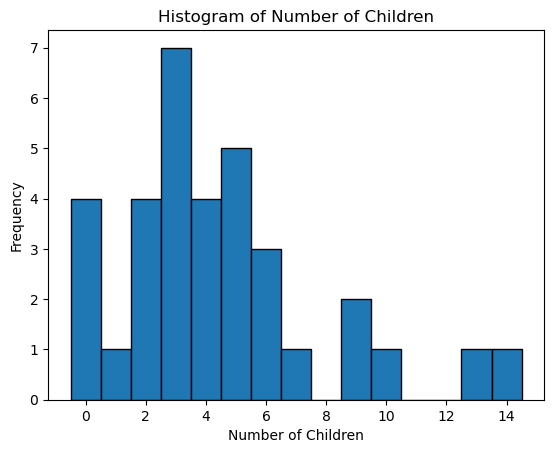

In [5]:
import matplotlib.pyplot as plt

# Extract list of values
values = numofchildren['Values']
#print(values)

# Plot the histogram
plt.hist(values, bins=range(0, max(values)), edgecolor='black', align='left')
plt.xlabel("Number of Children")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Children")

### 1.2 Inferential statistics

Inferential statistics is exactly what you think it means; infering from data some form of conclusion or judgement specifically extrapolating from 
a sample of data something about a population. It is usually impractical to try and measure some attribute from a population that could be in the
thousands, millions or even billions.

The process, briefly explained,  involves overlaying a well known statistical model to sample data in order to help answer questions about a population. Most common basic models are: Normal distribution, Exponential distribution, Poison distribution, Bernoulli distribution etc.

I managed to find some data on "the average heights and weights for American women aged between 30 to 39" from Wolfram Data Repository:

| Height | Weight |
| --- | --- |
| 58 in | 115 lb |
| 59 in | 117 lb |
| 58 in | 120 lb |
| 59 in | 123 lb |
| 60 in | 126 lb |
| 61 in | 129 lb |
| 62 in | 132 lb |
| 63 in | 135 lb |
| 64 in | 139 lb |
| 65 in | 142 lb |
| 66 in | 142 lb |
| 67 in | 146 lb |
| 68 in | 150 lb |
| 69 in | 154 lb |
| 70 in | 159 lb |
| 71 in | 155 lb |
| 72 in | 164 lb |

I want to infer something from this sample data about the general population from which the data was taken from namely the mean and the 95% confidence interval around the mean i.e. the range of the mean within a 95% confidence interval.



In [4]:
import numpy as np
import scipy.stats as stats

w_height = [58, 59, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
confidence_level = 0.95
mean = np.mean(w_height)
sem = stats.sem(w_height) # standard error i.e. standard deviation of a sample mean
confidence_interval = stats.t.interval(confidence_level, len(w_height)-1, loc=mean, scale=sem)

print(f"Mean: {mean}")
print(f"95% Confidence Interval: {confidence_interval}")


Mean: 64.23529411764706
95% Confidence Interval: (61.81324936559018, 66.65733886970393)


So the average height of American women aged 30-39 is 64 inches and the 95% confidence interval implies that we are 95% confident that the true population mean of womens height in that cohort lies between 61.81 and 66.66. 

Actually what the 95% confidence interval really means is that if the sampling procedure were repeated a large number of times, then about 5% of the intervals generated completely miss the population mean i.e. the population mean would not be found in the particular instance i.e. the population mean would be outside that interval

# 1.3 Sampling

It's not practical to gather all the data from a population hence taking a sample from a population to understand something about that population is the more realistic and practical scenario. We want to ensure that the sample we take is representative as best as is possible of the population we are taking the sample from.

The most common sampling methodology are listed below:

- <b>Simple Random Sampling or SRS</b>:
  This just means collecting a random sample from a population. It could be by labelling and then randomising those labels so that each member of the population as an equal chance of being picked. However, it should be noted that using this method does not gurranttee a random sample as the population may not be randomly balanced for some characteristics that we are looking for e.g. age
- <b>Stratified Sample</b>:
  This technique can overcome some of the shortcomings in the SRS technique when sampling from a population i.e. preventing unwanted biases. For example, when sampling a population of people the population can be divided into subgroups called strata (e.g. age, gender etc) and a sample taken from each strata. This ensures each subgoup is represented in the sample and we don't get biased or unrepresentative samples from a population.
- <b>Systematic Sampling</b>: This technique involves taking every nth member of the population and is suitable for large populations with minimal  variations. In order to carry out this technique determine the sample size and the population size, divide the population size by the sample size which gives the interval. The interval is then used for 'every nth' e.g. from a population of 1000 with a sample size of 100 means chosing every 10th item from an ordered population list starting randomly anywhere between 1 and 10.

Here is an example of random sampling from a population size of 1000

In [5]:
import numpy as np

# create a population f 1000 values i.e. return a numpy array numbered from 1 to 1000
population  = np.arange(1, 1001)
# print(population)
# select a random sample of 10 values
sample = np.random.choice(population, size=10, replace=False)
print(f"Randon sample {sample}")


Randon sample [428 752 269 373  99 977 280 172 309 463]


Here is an exampe of systematic sampling with a population size of 1000 and a sample size of 100

In [13]:
import numpy as np

population_size = 1000
sample_size = 100

# create a population as a list from 1 to 1000
population = list(range(1, population_size + 1))

# Calculate the k sampling interval
k = population_size // sample_size

# Now randomly select a starting point between 1 and 10 
# Set the seed so as to get the same starting_point everytime the code is run
np.random.seed(42)
starting_point = np.random.randint(0, k) 

# Select every nth item from from the population starting from the starting_point
samples = [population[i] for i in range(starting_point, population_size, k)]
print(f"Every {k} element from population: \n {samples}")

Every 10 element from population: 
 [7, 17, 27, 37, 47, 57, 67, 77, 87, 97, 107, 117, 127, 137, 147, 157, 167, 177, 187, 197, 207, 217, 227, 237, 247, 257, 267, 277, 287, 297, 307, 317, 327, 337, 347, 357, 367, 377, 387, 397, 407, 417, 427, 437, 447, 457, 467, 477, 487, 497, 507, 517, 527, 537, 547, 557, 567, 577, 587, 597, 607, 617, 627, 637, 647, 657, 667, 677, 687, 697, 707, 717, 727, 737, 747, 757, 767, 777, 787, 797, 807, 817, 827, 837, 847, 857, 867, 877, 887, 897, 907, 917, 927, 937, 947, 957, 967, 977, 987, 997]


## 2. Calculus
Let's move on to Calculus

I couldn't imagine Calculus and it's use in data science/machine learning until I first started getting interested in the subject. However, Calculus is so useful in solving many problems that it shouldn't be surprising if it makes a useful appearance in the data science/machine learning arena.

<b>A little bit about functions...</b>

-------------------------------------------------------------------------------------------------------------------------------------------------------
You need functions to work on when using Calculus and most natural phenomena around us can be modelled as functions. Furthermore, functions take in inputs, apply a process and spit out an output. And if we can define a function for a process we can get more insights about a process which can be used to make predictions, describe that process etc.

Mathematicians define functions very strictly and are interested in the relationship of change between one variable and another e.g. the relationship between y and x. They have thus defined functions as:

1. Having an input (domain) into the function which has exactly one output (codomain) <b>and not more</b>
2. Some outputs (codomain) do not necessarily have to result from an input to a function i.e. some outputs are always excluded for example the function $f(x)=x^2$ excludes all negative numbers as its output.

An example of a more invloved function is: $s = ut + \frac{1}{2}at^2$. This is the relationship in Physics between displacement $s$ (a vector quantity that ignores distance and considers on how much something has move from point a to point b by a straight line) and time $t$ with a constant term $a$ for acceleration due to gravity. 

This is a quadratic function because of the power of 2 on the $t$ variable. 

For example, if you throw a ball directly upwards with a known initial velocity $u$ you could technically figure out how high it would reach at any point in time. Since the function is a quadratic you could calculate at what time it would reach it's maximum height or at what time it would hit the ground (in the later simply solving the quadratic eqaution as you would when you were at school by equating the equation to zero (because time equal to zero is when the ball has landed on the ground) $s = ut + \frac{1}{2}at^2 = 0$ and solving for $t$).

An interesting fact is that if you differentiate (*see Derivatives below*) $s = ut + \frac{1}{2}at^2$ that leads to the equation for calculating the velocity of the ball as: $v = u + at$. If you differentiate the displacement function a second time (known as the second derivative) you will have an equation for acceleration.

-------------------------------------------------------------------------------------------------------------------------------------------------------
I believe machine learning models work (in naive terms) on maximising or minimising some given objective function especially when it is training i.e. optimising it for a given task. The first derivative gives the rate of change of one variable (input) against another variable (output) and the maximum and minimum points can be determined from the first derivative too (since that is the point when the rate equals 0 and by solving a derivative function at $f(x)'=0$ we can get the minimum or maximum value) and I think the machine then figures out by trial and error (with training) which steps will get it to that optimised (minimum or maximum) value (a process called gradient descent).

### 2.1 Derivatives

Anyway, moving onto derivatives (some of which has been discussed above). A derivative is function which can be used to workout the rate of change of one variable with regards to another variable and the process of working out a derivative is called differentiation. 

You don't need differentition for a linear function because the rate of change is constant and can just be worked out by dividing y by x. However the blessings of defferentiation come when trying to understand non-linear functions where the rate if change is is not constant but varies along the entirety of the function (dividing y by x would only give you the average rate of change not a specific rate of change at a particular x).

As already mentioned first derivatives can be used to work out a maximum or a minimum value of a function and this can be useful in machine learning because a machine is trying to get to this optimum (maximum or minimum) value and by extension the optimum model.

A quick example of using Python to find the derivative of a simple function is shown below.

The simple function is: $f(x)=x^2 + 2x +1$ and it is also plotted in Desmos for reference.

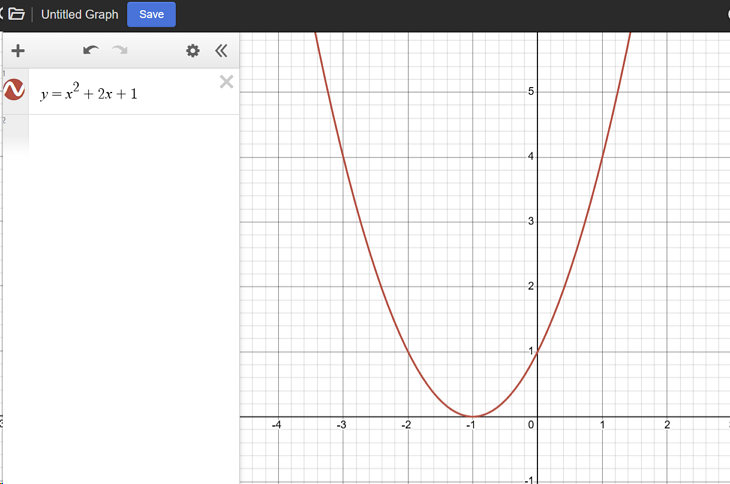

In [3]:
import sympy as sp

# define the variable x and function f(x)
x = sp.Symbol('X')
f = x**2 + 2*x + 1
print(f"f(x)= {f}\n")

# calculate the derivative
derivative = sp.diff(f, x)

print("Derivative of f(x):")
print(derivative)


f(x)= X**2 + 2*X + 1

Derivative of f(x):
2*X + 2


Just to double check let's use Symbolab.

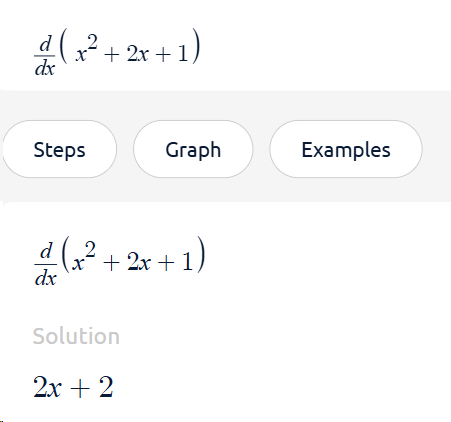

### 2.2 Gradient Descent

So gradient descent is an iterative optimisation algorithm that gets a machine closer and closer to the minimum or maximum point by using:

1. An estimate (guess) of a value which you want to reduce to 0 i.e. your starting point
2. The derivate of the function
3. And a learning rate i.e. the step size to iterated to get to 0

<b>Illustration with example function</b>:

1. Take the function: $f(x) = (x-3)^2$; it's a parabola as illustrated by the graphing from Desmos

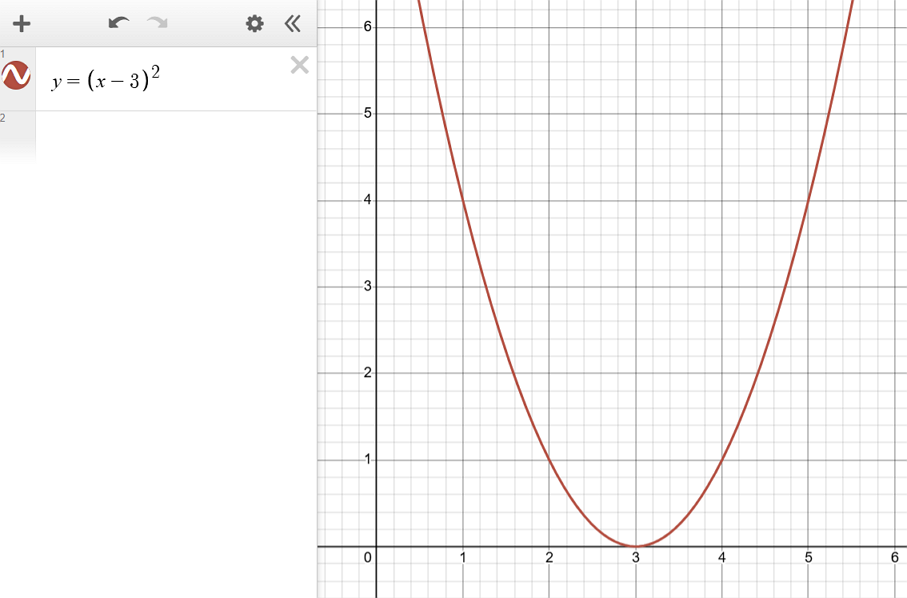

2. Take it's derivative: $f(x)' = 2(x-3)$
3. Choose an initial estimate for $x_0$ e.g. $x_0 = 0$ and learning rate $\eta>0$ e.g. $\eta=0.1$
4. Then iteratley apply the update rule to reach the value of approximately: $x_{n+1} \;=\; x_n \;-\;\eta\,f'(x_n)\;=\;x_n \;-\;2\eta\,(x_n-3)$

Gradient descent in Python looks like the following below. 

The point is there is a complex function and we don't know where it's minimum value is (the above function was a simple one which could be worked out by hand) and we guessed a starting value of $x = 0$ and worked our way iteratively to a value of $x = 3$.

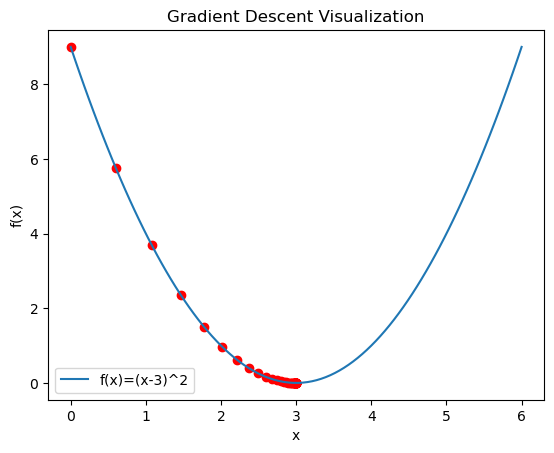

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# define the function and its derivative
def f(x):
    return (x-3)**2
def df(x):
    return 2*(x-3)

# define the initial estimate and learning rate
x = 0 # inital estimate
learning_rate = 0.1
n_iterations = 50

# perform gradient descent
x_values = [x]
for _ in range(n_iterations):
    gradient =df(x)
    x = x - learning_rate * gradient
    x_values.append(x)

# plot the function and descent path
x_range = np.linspace(0, 6, 100)
y_range = f(x_range)
plt.plot(x_range, y_range, label='f(x)=(x-3)^2')
plt.scatter(x_values, [f(i) for i in x_values], color='red')
plt.title('Gradient Descent Visualization')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

## 3. Linear Algebra

Linear algebra is kind of hard to define even though everyone has heard of it. For the purposes of this guide Linear Algebra is a branch of mathematics that grew out of the solution of systems of linear equations. By having the linear equations in matrix forms then all the operations known to matrices can be used to solve those equations.

Linear algerba lies at the heart of many machine learning models such as neural networks.

Some useful applications of matrices:

1. <u>Computer Science</u>: <br>

   **a**. Vectorised code (array programming) i.e. using linear algebra to compute many values simultaneously e.g. using matrices is much faster than using loops to iterate calculations involving the same coefficients in the case where there is say some fixed cost (coefficient) plus a unit rate (coefficient) times a unit variable then we could easily loop through each unit variable and plugging those into the equation one at a time in a for loop. This is not very efficient computationally if there are thousands or millions of these variables.

   An alternative way is to arrange the variables and coefficients in matrices and perform a matrix multiplication (much faster)

   **b**. Image recognition i.e. for storing images in matrix form for use in deep neural networks e.g. an image of a dog consisting of the Red, Green and Blue scale can be broken down into a rank 3 tensor (a sort of <u>k by m by n*</u> matrix or basically 3 2-dimensional matrices with each 2 dimensional matrix representing R G B).

2. <u>Physics</u>: <br>

    **a**. Vectors. Matrices can be used in calculating displacements in say 3 dimensions by storing each x, y, z coordinate in column vector and adding the before and after coordinates simply by adding the same components together i.e. all the x, y and z coordinates.



### 3.1 Vectors and Matrices

As mentioned before in the above paragraph matrices are used to store data points (normally stored across rows) and the columns in these matrices represent the features for example a column could represent a feature called age or city or cost or price. Features are measurable properties or attributes of the data being analysed.

A simple dsiplay of a vector and a matrix in Python.

Note that vectors essentially can store components of n dimension so for example a 3-dimensional vector stores 3 components x, y and z in 3 dimensions and you can go up to n-dimensions.

A matrix could possible be seen as a collection of vecotrs but that is not strictly true. In one sense a column vector can be seen as a 3 by 1 matrix but a vector specifically deals with points in space whereas a matrix can be used to solve linear equations and do more mathematical tricks!

A matrix can be more accurately described as an array of numbers arranged in rows and columns and can be used for storing data or solving systems of equations.

In [1]:
# import libraries
import numpy as np

# define a vector
vector = np.array([1, 2, 3])
print("Vector:")
print(f'{vector}\n')

# define a matrix
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("Matrix:")
print(matrix)

Vector:
[1 2 3]

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 3.2. Matrix Operations

There are certain operations that can be performed on matrices. The common ones are: addition and substration; scalar multiplication; matrix multiplication; transposition; inversion and determinant.

#### 1. Addition and Substraction

Addition and substraction of matrices can only be performed if they have the same dimensions i.e. same number of rows and columns. Note that each corresponding (row, column) from each matrix is added or substracted together so in the addition example (3+3, 5+5, 7+1, 2+1.....etc)

*Example:*

**Matrix addition**
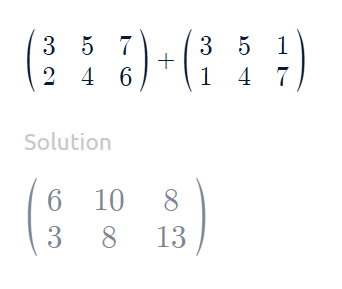

**Matrix substraction**
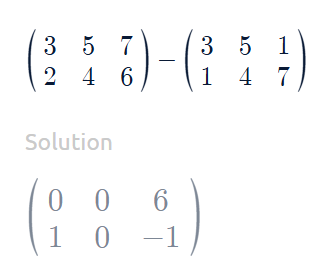

#### Matrix addition in python using above example

In [4]:
import numpy as np

# Define the first matrix (A)
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Define the second matrix (B)
B = np.array([[3, 5, 1],
              [1, 4, 7]])

# Perform matrix addition.
C = A + B

# Print the result
print(C)

[[ 6 10  8]
 [ 3  8 13]]


#### Matrix substraction in python using above example

In [3]:
import numpy as np

# Define the first matrix (A)
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Define the second matrix (B)
B = np.array([[3, 5, 1],
              [1, 4, 7]])

# Perform matrix addition.
C = A - B

# Print the result
print(C)

[[ 0  0  6]
 [ 1  0 -1]]


#### 2. Scalar multiplication
This is multiplying a matrix by a single number (called a scaler; a scaler is a single number that often represents size or magnitude with no dimensions of its own). 

Scalar multiplication can be viewed as expansion in all directions by a certain size; like blowing up a balloon.

*Example:*

**Scalar multiplication**
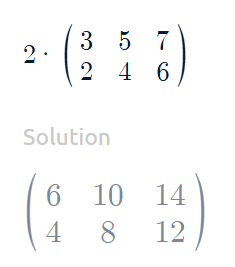

#### Scalar multiplication in python using above example

In [10]:
import numpy as np

# Define the matrix
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Perform matrix addition.
C = 2*A

# Print the result
print(C)

[[ 6 10 14]
 [ 4  8 12]]


#### 3. Matrix multiplication (dot product)
Matrix multiplication is just slightly more complicated/convoluted. When multiplying 2 matrices together the number of columns in matrix A must be the same number as the number of rows in B.

Then the process is: multiply the rows of the first matrix by the columns of the second matrix (repeatedly)

It is easier to illustrate grahically than to describe (as below):
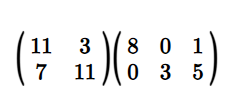
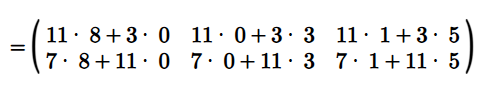

Note that matrix multiplication are not communitative like regular multiplication of integers e.g. $3\times4 = 4\times3$ but with matrices $AB \neq BA$ for obvious reasons order matters when you start switching matrices around proceeding in a different order can give different results.

*Example:*
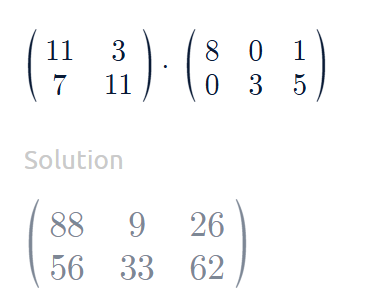



#### Matrix transpotion in python using above example

In [3]:
import numpy as np

# Define the matrix
A = np.array([[11, 3],
              [7, 11]])

# Perform matrix addition.
B = np.array([[8, 0, 1],
              [0, 3, 5]])

C = np.dot(A,B)

# Print the result
print(C)

[[88  9 26]
 [56 33 62]]


#### 4. Transpose 

Matrix transposition is simply interchanging rows and columns i.e. flipping all the row elements into columns and all the column elements into rows. Useful applications including the saving of space by being able to transpose long column matrices into more compact row matrices. An illustration is shown below for clarity:
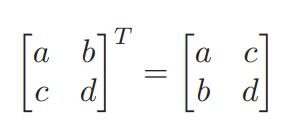

*Example:*

**Matrix transposition**

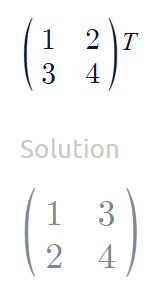


#### Matrix transpotion in python using above example

In [2]:
import numpy as np

# 1. Create the matrix
matrix = np.array([[1, 2], 
                   [3, 4]])

# 2. Perform the transposition
transpose_matrix = matrix.T

print("Original Matrix:")
print(matrix)

print("\nTransposed Matrix:")
print(transpose_matrix)

Original Matrix:
[[1 2]
 [3 4]]

Transposed Matrix:
[[1 3]
 [2 4]]


#### 5. Inverse of a matrix
The inverse of a matrix is sort of like the "opposite" of a matrix or more formally: when a matrix is multiplied by it's inverse you get the identity matrix.

*Example:*

**Inverse of a matrix**

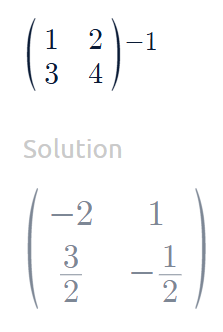

And then when you multiply the matrix by it's inverse you get the identity matrix:
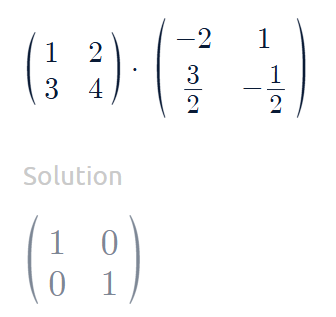

Which is conceptually like multiplying any number by 1 which returns the original number e.g.
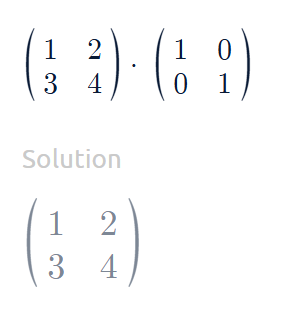

#### Matrix (find the inverse) in python using above example

In [5]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Calculate the inverse
A_inv = np.linalg.inv(A)
print(A_inv)

[[-2.   1. ]
 [ 1.5 -0.5]]


#### Matrix multiplication by its inverse in python using above example

In [9]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Perform matrix addition
B = np.array([[-2, 1],
              [1.5, -0.5]])

C = np.dot(A,B)
# C = A * B

# Print the result
print(C)

[[1. 0.]
 [0. 1.]]


#### Matrix multiplication by identity matrix in python using above example

In [11]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Perform matrix addition
B = np.array([[1, 0],
              [0, 1]])

C = np.dot(A,B)
# C = A * B

# Print the result
print(C)

[[1 2]
 [3 4]]


###  3.3. Eigenvalues and Eigenvectors

Eigenvalues and Eigenvectors are scalars and vectors respectively which are associated with a matrix with heavy application in Physics and Mathematics in general. 

*Eigenvalues: are simply numbers with no other information for example speed tells us how fast a car is travelling but doesn't tell us in which direction it is travelling.*  

*Eigenvectors: is a value with other information such as direction for example a car travelling at 30mph south.*



### Eigenvectors in context

Normally we can use matrices to apply linear transformation on vectors in the cartessian coordinate system from say coordinates ($x_{0},y_{0}$) to coordinates ($x_{1},y_{1}$) as follows:

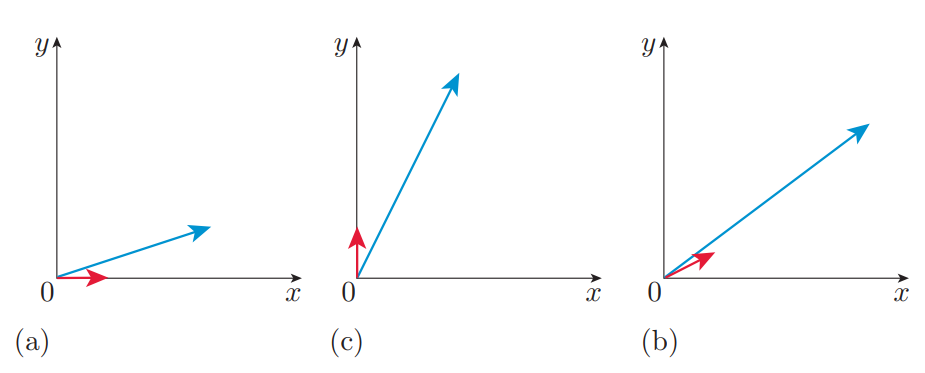

*Initial vector being red and transformed vector being blue*

The linear transformation would be applied using a standard matrix mulptilation with the format below:

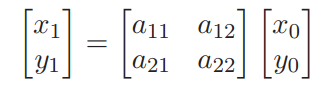

However, there is one circumstance where the vector given only has it's magnitude changed but not it's direction.